# Synthetic Graph Suite (10 per family)

This notebook generates 10 graphs per family (varying nodes + density where applicable), labels density as sparse/medium/dense, and computes diameter, runtime, memory, BFS passes, and edge checks for k-BFS and Takes-Kosters.

Note: Some families have fixed density by definition (clique = 1, path/tree/grid are structurally sparse). For those, we vary node count only; for bipartite, small_world, and scale_free we vary density-related parameters too.

In [13]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve()))

from scripts.synthetic_suite import generate_suite

In [14]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = generate_suite(k=4)

per_graph_table = df[[
    "graph_family",
    "nodes",
    "edges",
    "density",
    "density_bucket",
    "exact_diameter",
    "k_bfs_diameter",
    "tk_diameter",
    "k_bfs_abs_error",
    "tk_abs_error",
    "k_bfs_time",
    "tk_time",
    "k_bfs_peak_mb",
    "tk_peak_mb",
    "k_bfs_bfs_passes",
    "tk_bfs_passes",
    "k_bfs_edge_checks",
    "tk_edge_checks",
]]

family_density_table = df.groupby(["graph_family", "density_bucket"])[
    [
        "nodes",
        "edges",
        "density",
        "exact_diameter",
        "k_bfs_abs_error",
        "tk_abs_error",
        "k_bfs_time",
        "tk_time",
        "k_bfs_peak_mb",
        "tk_peak_mb",
    ]
].mean().reset_index()

family_summary = df.groupby("graph_family")[
    [
        "nodes",
        "edges",
        "density",
        "exact_diameter",
        "k_bfs_abs_error",
        "tk_abs_error",
        "k_bfs_time",
        "tk_time",
    ]
].mean().reset_index().sort_values("graph_family")

per_graph_table, family_density_table, family_summary

(   graph_family  nodes  edges   density density_bucket  exact_diameter  k_bfs_diameter  tk_diameter  k_bfs_abs_error  tk_abs_error  k_bfs_time    tk_time  k_bfs_peak_mb  tk_peak_mb  \
 0        clique     50   1225  1.000000          dense               1               1            1                0             0    0.012146   0.112077       0.004837    0.003354   
 1          path     50     49  0.040000         sparse              49              49           49                0             0    0.010387   0.000308       0.003220    0.002419   
 2          tree     50     49  0.040000         sparse              13              13           13                0             0    0.003304   0.000997       0.003281    0.002480   
 3          grid     56     97  0.062987         medium              13              13           13                0             0    0.005980   0.000903       0.003754    0.002663   
 4     bipartite     13      7  0.089744         medium               2    

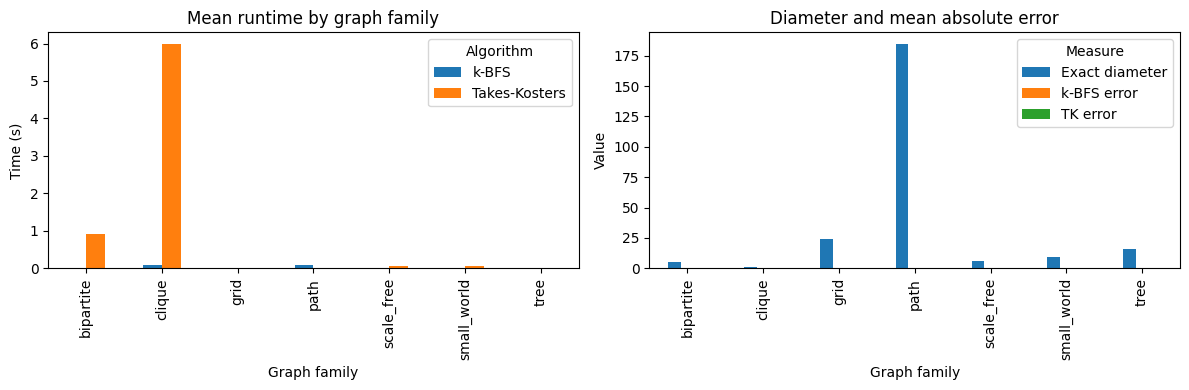

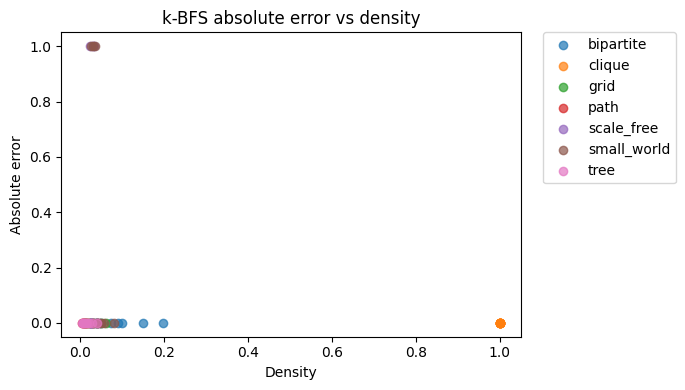

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

family_summary.set_index("graph_family")[["k_bfs_time", "tk_time"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean runtime by graph family")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlabel("Graph family")
axes[0].legend(["k-BFS", "Takes-Kosters"], title="Algorithm")

family_summary.set_index("graph_family")[["exact_diameter", "k_bfs_abs_error", "tk_abs_error"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Diameter and mean absolute error")
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Graph family")
axes[1].legend(["Exact diameter", "k-BFS error", "TK error"], title="Measure")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for family, group in df.groupby("graph_family"):
    ax.scatter(group["density"], group["k_bfs_abs_error"], label=family, alpha=0.7)
ax.set_title("k-BFS absolute error vs density")
ax.set_xlabel("Density")
ax.set_ylabel("Absolute error")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.tight_layout()
plt.show()

## Interpretation guide (what to expect)
- Clique: diameter near 1, errors near 0, runtimes low for both.
- Path/grid/tree: larger diameters, k-BFS error can increase if $k$ is small.
- Small-world: low diameter, k-BFS tends to match exact.
- Scale-free: accuracy varies based on hub selection; error can be higher on some seeds.
- Bipartite: diameter depends on density; sparse bipartite graphs tend to have larger diameter.